# Model 1 — Hosting Recommendation Classifier
## Complete training, comparison, evidence and model export

This notebook is the evidence notebook for completely training/evaluating the main classification model of the **AI Web Hosting Advisor** project.

**Target:** `VPS`, `CLOUD_VM`, `KUBERNETES`

Compared models:

1. `LogisticRegression`
2. `DecisionTreeClassifier`
3. `RandomForestClassifier`
4. `XGBoost (XGBClassifier)`

### Dataset usage
- Main dataset rows: **5,000**
- Split for unbiased model selection/evaluation: **3,500 train + 750 validation + 750 test = 5,000 rows**
- Model selection uses validation **Macro F1**.
- Test set is untouched until the model-selection decision is made.
- After evaluation, **every candidate model is refit on all 5,000 rows and saved** as a production artifact.
- The selected model is also saved separately for backend use.

> Important methodology note: the 5,000 hosting rows are transparently expert-rule-assisted semi-synthetic scenarios calibrated using public workload/hardware evidence. Public cluster traces do not contain direct `VPS / CLOUD_VM / KUBERNETES` ground-truth labels.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate # Import StratifiedKFold and cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # Initialize StratifiedKFold for 5-fold cross-validation
cv_classifier_rows = [] # List to store cross-validation results
for name, template in CANDIDATES.items():
    started = time.perf_counter() # Start timer
    scores = cross_validate(
        clone(template), df[FEATURES], df[TARGET], cv=cv,
        scoring={"accuracy":"accuracy", "f1_macro":"f1_macro"},
        n_jobs=1, return_train_score=False
    ) # Perform cross-validation
    cv_classifier_rows.append({
        "model": name,
        "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])), # Mean test accuracy
        "cv_accuracy_std": float(np.std(scores["test_accuracy"])), # Standard deviation of test accuracy
        "cv_f1_macro_mean": float(np.mean(scores["test_f1_macro"])), # Mean test Macro F1
        "cv_f1_macro_std": float(np.std(scores["test_f1_macro"])), # Standard deviation of test Macro F1
        "cv_seconds": time.perf_counter()-started, # Cross-validation time
    }) # Append results to list
cv_classifier_df = pd.DataFrame(cv_classifier_rows).sort_values("cv_f1_macro_mean", ascending=False) # Create DataFrame of cross-validation results, sorted by mean f1_macro
cv_classifier_df.to_csv(RESULT_DIR / "10_five_fold_cv_comparison.csv", index=False) # Save cross-validation results to CSV
display(cv_classifier_df) # Display cross-validation results

ax = cv_classifier_df.set_index("model")[["cv_accuracy_mean", "cv_f1_macro_mean"]].plot(
    kind="bar", title="Five-fold cross-validation — all 5,000 rows"
) # Plot mean cross-validation scores
ax.set_ylim(0.80, 1.00) # Set y-axis limits
ax.set_ylabel("Mean CV score") # Set y-axis label
plt.xticks(rotation=20) # Rotate x-axis labels
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "10_five_fold_cv_comparison.png", dpi=160) # Save the plot
plt.show() # Display the plot

lr_cv = cv_classifier_df.loc[cv_classifier_df["model"]=="LogisticRegression"].iloc[0] # Get Logistic Regression CV results
xgb_cv = cv_classifier_df.loc[cv_classifier_df["model"]=="XGBoost"].iloc[0] # Get XGBoost CV results
print("Logistic Regression 5-fold Macro F1:", round(lr_cv["cv_f1_macro_mean"],6))
print("XGBoost 5-fold Macro F1:", round(xgb_cv["cv_f1_macro_mean"],6))
print("Difference XGB - LR:", round(xgb_cv["cv_f1_macro_mean"]-lr_cv["cv_f1_macro_mean"],6))
print("\nSelection honesty note:")
print("• Logistic Regression won the predeclared 750-row validation split.")
print("• XGBoost is a very close/strong alternative and may lead on 5-fold CV or the untouched test set.")
print("• Therefore 'Logistic is selected' should be stated as the project selection decision, not as proof that it dominates every possible evaluation.") # Provide selection honesty note

In [ ]:
from pathlib import Path
import sys, json, time, warnings, shutil
warnings.filterwarnings("ignore") # Ignore warnings during execution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Package path works both when executed from /notebooks and package root.
CWD = Path.cwd().resolve()
PACKAGE_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
sys.path.insert(0, str(PACKAGE_ROOT))
from ml_helpers import StringLabelXGBClassifier # Custom XGBoost classifier that handles string labels

DATA_PATH = PACKAGE_ROOT / "dataset" / "hosting_advisor_master_5000.csv" # Path to the main dataset
EXT_PATH = PACKAGE_ROOT / "dataset" / "independent_validation_cases_300.csv" # Path to the independent validation dataset
MODEL_EVAL_DIR = PACKAGE_ROOT / "models" / "classifier" / "evaluation" # Directory for evaluation models
MODEL_PROD_DIR = PACKAGE_ROOT / "models" / "classifier" / "production" # Directory for production models
RESULT_DIR = PACKAGE_ROOT / "results" / "classifier" # Directory for results
CHART_DIR = PACKAGE_ROOT / "charts" / "classifier" # Directory for charts
for p in [MODEL_EVAL_DIR, MODEL_PROD_DIR, RESULT_DIR, CHART_DIR]:
    p.mkdir(parents=True, exist_ok=True) # Create directories if they don't exist

SEED = 6002 # Random seed for reproducibility
CLASS_LABELS = ["VPS", "CLOUD_VM", "KUBERNETES"] # Define class labels
print("Package root:", PACKAGE_ROOT)
print("Dataset:", DATA_PATH)

Package root: /mnt/data/AI-Web-Hosting-Advisor-ML-Notebooks-Complete
Dataset: /mnt/data/AI-Web-Hosting-Advisor-ML-Notebooks-Complete/dataset/hosting_advisor_master_5000.csv


## 1. Load the complete 5,000-row dataset and verify integrity

In [ ]:
df = pd.read_csv(DATA_PATH) # Load the main dataset
ext = pd.read_csv(EXT_PATH) if EXT_PATH.exists() else None # Load the external validation dataset if it exists

print("Main dataset shape:", df.shape)
print("Duplicate full rows:", int(df.duplicated().sum()))
print("Unique row_id values:", df["row_id"].nunique())
print("USD budget column present:", "budget_usd" in df.columns)
print("Independent scenario set:", None if ext is None else ext.shape)

assert len(df) == 5000, "Expected exactly 5,000 rows" # Assert that the main dataset has 5000 rows
assert df["row_id"].nunique() == 5000, "row_id must be unique" # Assert that 'row_id' is unique
assert df.duplicated().sum() == 0, "Full duplicate rows found" # Assert that there are no duplicate rows
assert "budget_usd" in df.columns # Assert that 'budget_usd' column is present

display(df.head(8)) # Display the first 8 rows of the dataframe

Main dataset shape: (5000, 35)
Duplicate full rows: 0
Unique row_id values: 5000
USD budget column present: True
Independent scenario set: (300, 36)


,row_id,project_mode,app_type,monthly_users,expected_concurrent_users,requests_per_user_min,estimated_rps,peak_rps,peak_multiplier,budget_usd,storage_gb,performance_score,performance_available,cdn_present,database_intensity,api_intensity,realtime_required,realtime_connections,background_jobs,media_heavy,growth_rate,operational_skill,availability_level,high_availability,traffic_pattern,multi_region_required,autoscaling_required,managed_database_preferred,hosting_type,recommended_vcpu,recommended_ram_gb,label_confidence,label_method,calibration_source,synthetic
0,WH-00001,LIVE_URL,SAAS,670496,38,7.73,4.90,6.66,1.36,46.00,159.4,61.0,1,0,VERY_HIGH,HIGH,0,0,0,0,MEDIUM,INTERMEDIATE,99.9,0,NORMAL,0,0,1,CLOUD_VM,2,16,0.980,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
1,WH-00002,LIVE_URL,ECOMMERCE,442308,3286,6.37,348.86,519.81,1.49,241.81,32.1,NaN,0,0,MEDIUM,HIGH,0,0,1,0,RAPID,ADVANCED,99.95,1,NORMAL,0,0,0,KUBERNETES,32,64,0.662,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
2,WH-00003,LIVE_URL,BLOG,69368,6,2.92,0.29,0.43,1.46,11.11,11.5,98.0,1,0,LOW,LOW,0,0,0,0,STABLE,BEGINNER,BASIC,0,BUSINESS_HOURS,0,0,0,VPS,1,4,0.980,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
3,WH-00004,PLANNED,BLOG,4653,25,2.11,0.88,1.31,1.49,20.97,17.3,NaN,0,0,LOW,LOW,0,0,0,0,SLOW,INTERMEDIATE,99.9,0,NORMAL,0,0,0,VPS,1,4,0.980,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
4,WH-00005,PLANNED,SAAS,1219194,3981,14.86,985.96,2839.57,2.88,936.99,752.8,NaN,0,1,HIGH,HIGH,0,0,0,1,STABLE,ADVANCED,99.95,1,EVENT_DRIVEN,1,0,0,KUBERNETES,32,64,0.980,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
5,WH-00006,LIVE_URL,MARKETPLACE,172514,3358,6.35,355.39,1407.34,3.96,265.18,134.0,66.0,1,0,HIGH,HIGH,0,0,0,1,MEDIUM,ADVANCED,99.95,1,EVENT_DRIVEN,0,1,0,KUBERNETES,32,64,0.735,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
6,WH-00007,LIVE_URL,SAAS,149603,241,16.40,65.87,127.14,1.93,31.37,14.8,NaN,0,0,MEDIUM,HIGH,1,177,1,0,RAPID,ADVANCED,99.95,1,BUSINESS_HOURS,0,0,0,CLOUD_VM,8,16,0.980,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1
7,WH-00008,PLANNED,MARKETPLACE,519854,3109,14.29,740.46,2613.82,3.53,1268.00,117.4,NaN,0,1,MEDIUM,HIGH,1,1381,1,0,MEDIUM,ADVANCED,99.9,0,EVENT_DRIVEN,1,0,0,KUBERNETES,32,64,0.980,EXPERT_RULE_ASSISTED_SYNTHETIC,UCI_COMPUTER_HARDWARE+GOOGLE_CLUSTER_SAMPLE+AL...,1


,rows,percentage
hosting_type,,
VPS,1750,35.0
CLOUD_VM,2000,40.0
KUBERNETES,1250,25.0


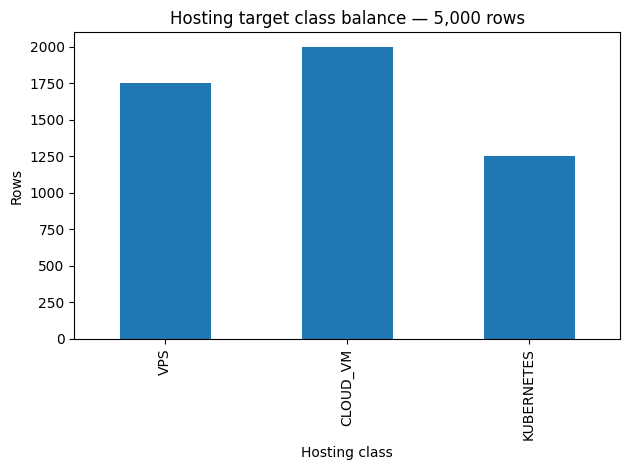

In [ ]:
class_counts = df["hosting_type"].value_counts().reindex(CLASS_LABELS) # Get counts of each hosting type
class_pct = (class_counts / len(df) * 100).round(2) # Calculate percentage of each hosting type
class_summary = pd.DataFrame({"rows": class_counts, "percentage": class_pct}) # Create a summary DataFrame
display(class_summary) # Display the class summary

ax = class_counts.plot(kind="bar", title="Hosting target class balance — 5,000 rows") # Plot class balance
ax.set_xlabel("Hosting class") # Set x-axis label
ax.set_ylabel("Rows") # Set y-axis label
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "01_class_balance.png", dpi=160) # Save the plot
plt.show() # Display the plot

## 2. Feature contract and leakage prevention

Only **26 input features** that match the backend's runtime feature contract are provided to the model. Fields like `row_id`, target labels, recommended CPU/RAM, `label_method`, `label_confidence`, `calibration_source`, `synthetic` are not included as model inputs. This prevents label leakage.

In [ ]:
NUMERIC_FEATURES = [
    "monthly_users", "expected_concurrent_users", "requests_per_user_min", "estimated_rps", "peak_rps",
    "budget_usd", "storage_gb", "performance_score", "performance_available", "cdn_present",
    "realtime_required", "realtime_connections", "background_jobs", "media_heavy", "high_availability",
    "multi_region_required", "autoscaling_required", "managed_database_preferred"
] # List of numeric features
CATEGORICAL_FEATURES = [
    "project_mode", "app_type", "database_intensity", "api_intensity", "growth_rate", "operational_skill",
    "availability_level", "traffic_pattern"
] # List of categorical features
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES # Combined list of all features
TARGET = "hosting_type" # Target variable

print("Numeric features:", len(NUMERIC_FEATURES))
print("Categorical features:", len(CATEGORICAL_FEATURES))
print("Total model inputs:", len(FEATURES))
print("Target:", TARGET)

excluded = [c for c in df.columns if c not in FEATURES + [TARGET]] # Columns intentionally excluded from the model
print("Intentionally excluded columns:", excluded)

Numeric features: 18
Categorical features: 8
Total model inputs: 26
Target: hosting_type
Intentionally excluded columns: ['row_id', 'peak_multiplier', 'recommended_vcpu', 'recommended_ram_gb', 'label_confidence', 'label_method', 'calibration_source', 'synthetic']


## 3. Data quality analysis

In [ ]:
quality = pd.DataFrame({
    "dtype": df[FEATURES + [TARGET]].dtypes.astype(str), # Data types of features and target
    "missing": df[FEATURES + [TARGET]].isna().sum(), # Count of missing values
    "missing_pct": (df[FEATURES + [TARGET]].isna().mean() * 100).round(2), # Percentage of missing values
    "unique": df[FEATURES + [TARGET]].nunique(dropna=True) # Number of unique values
}) # Create a DataFrame to summarize data quality
display(quality) # Display the data quality summary

print("Performance score missing values are expected for PLANNED/NEW_IDEA modes and are imputed inside the pipeline.")

,dtype,missing,missing_pct,unique
monthly_users,int64,0,0.00,4933
expected_concurrent_users,int64,0,0.00,2060
requests_per_user_min,float64,0,0.00,2161
estimated_rps,float64,0,0.00,3698
peak_rps,float64,0,0.00,4003
budget_usd,float64,0,0.00,4052
storage_gb,float64,0,0.00,1943
performance_score,float64,3068,61.36,523
performance_available,int64,0,0.00,2
cdn_present,int64,0,0.00,2


Performance score missing values are expected for PLANNED/NEW_IDEA modes and are imputed inside the pipeline.


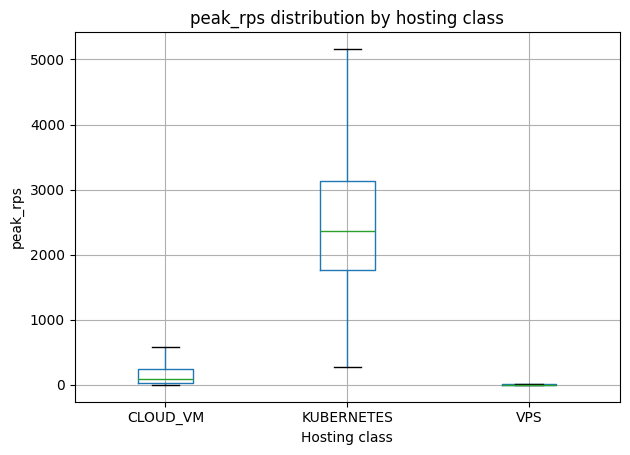

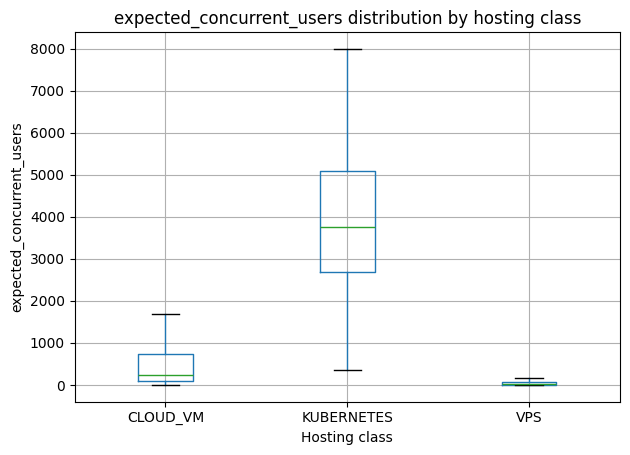

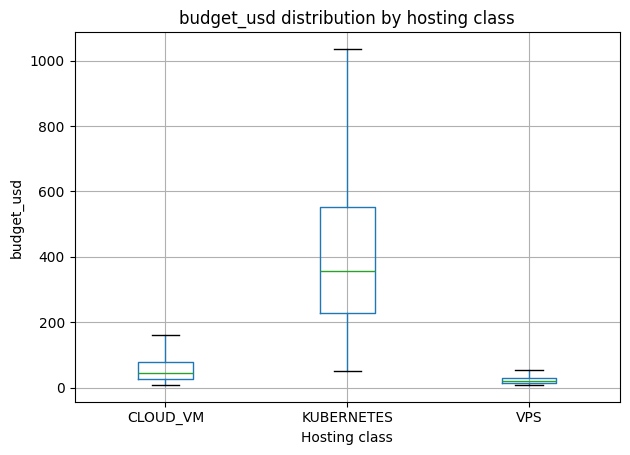

In [ ]:
# Three project-relevant numerical distributions by target class.
for col in ["peak_rps", "expected_concurrent_users", "budget_usd"]:
    ax = df.boxplot(column=col, by="hosting_type", showfliers=False) # Create box plots for numerical distributions by hosting type
    plt.suptitle("") # Remove default super title
    plt.title(f"{col} distribution by hosting class") # Set plot title
    plt.xlabel("Hosting class") # Set x-axis label
    plt.ylabel(col) # Set y-axis label
    plt.tight_layout() # Adjust layout
    plt.savefig(CHART_DIR / f"02_{col}_by_class.png", dpi=160) # Save the plot
    plt.show() # Display the plot

## 4. Correct train / validation / test split

- **Train = 70% = 3,500 rows**
- **Validation = 15% = 750 rows**
- **Test = 15% = 750 rows**

By using `stratify`, the three classes maintain a proportional distribution across all three splits.

In [ ]:
X = df[FEATURES].copy() # Features DataFrame
y = df[TARGET].copy() # Target Series

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
) # Split data into training and temporary sets (70% train, 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
) # Split temporary set into validation and test sets (15% val, 15% test)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test", "Total"],
    "rows": [len(X_train), len(X_val), len(X_test), len(df)]
}) # Create a summary of data splits
display(split_summary) # Display the split summary

for name, target in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(name, target.value_counts(normalize=True).reindex(CLASS_LABELS).round(4).to_dict()) # Print class distribution for each split

,split,rows
0,Train,3500
1,Validation,750
2,Test,750
3,Total,5000


Train {'VPS': 0.35, 'CLOUD_VM': 0.4, 'KUBERNETES': 0.25}
Validation {'VPS': 0.3507, 'CLOUD_VM': 0.4, 'KUBERNETES': 0.2493}
Test {'VPS': 0.3493, 'CLOUD_VM': 0.4, 'KUBERNETES': 0.2507}


## 5. Preprocessing

- Numeric missing values → median imputation.
- Logistic Regression numeric features → StandardScaler.
- Categorical values → most-frequent imputation + OneHotEncoder.
- Unknown categories at runtime are safely ignored by the encoder.

In [ ]:
def make_preprocessor(scale_numeric=False):
    num_steps = [("impute", SimpleImputer(strategy="median"))] # Step for median imputation of numeric features
    if scale_numeric:
        num_steps.append(("scale", StandardScaler())) # Add StandardScaler if scaling is enabled
    return ColumnTransformer([ # Create a ColumnTransformer for preprocessing
        ("num", Pipeline(num_steps), NUMERIC_FEATURES), # Pipeline for numeric features
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), CATEGORICAL_FEATURES) # Pipeline for categorical features with most frequent imputation and one-hot encoding
    ])


def classification_metrics(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0) # Calculate macro precision, recall, f1-score
    pw, rw, fw, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0) # Calculate weighted precision, recall, f1-score
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)), # Accuracy score
        "precision_macro": float(p),
        "recall_macro": float(r),
        "f1_macro": float(f),
        "precision_weighted": float(pw),
        "recall_weighted": float(rw),
        "f1_weighted": float(fw),
    } # Return a dictionary of classification metrics

## 6. Define the four requested candidate models

In [ ]:
CANDIDATES = {
    "LogisticRegression": Pipeline([
        ("pre", make_preprocessor(scale_numeric=True)), # Preprocessor with numeric scaling
        ("model", LogisticRegression(
            max_iter=3000, class_weight="balanced", random_state=SEED
        )) # Logistic Regression model
    ]),
    "DecisionTree": Pipeline([
        ("pre", make_preprocessor(scale_numeric=False)), # Preprocessor without numeric scaling
        ("model", DecisionTreeClassifier(
            max_depth=14, min_samples_leaf=6,
            class_weight="balanced", random_state=SEED
        )) # Decision Tree Classifier model
    ]),
    "RandomForest": Pipeline([
        ("pre", make_preprocessor(scale_numeric=False)), # Preprocessor without numeric scaling
        ("model", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight="balanced_subsample", n_jobs=-1,
            random_state=SEED
        )) # Random Forest Classifier model
    ]),
    "XGBoost": Pipeline([
        ("pre", make_preprocessor(scale_numeric=False)), # Preprocessor without numeric scaling
        ("model", StringLabelXGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.05,
            subsample=0.90, colsample_bytree=0.90,
            random_state=SEED, n_jobs=-1, reg_lambda=1.0
        )) # XGBoost Classifier model (custom for string labels)
    ]),
} # Dictionary of candidate models
list(CANDIDATES) # Display the names of the candidate models

['LogisticRegression', 'DecisionTree', 'RandomForest', 'XGBoost']

## 7. Train on 3,500 rows and compare on the 750-row validation set

**Selection rule:** highest validation `Macro F1`; if tied, highest accuracy. Macro F1 matters because all three hosting classes should perform well rather than letting the largest class dominate the decision.

In [ ]:
validation_rows = [] # List to store validation results
validation_models = {} # Dictionary to store trained validation models

for name, template in CANDIDATES.items():
    model = clone(template) # Clone the model template
    started = time.perf_counter() # Start timer
    model.fit(X_train, y_train) # Train the model on the training data
    fit_seconds = time.perf_counter() - started # Calculate fitting time
    pred = model.predict(X_val) # Make predictions on the validation set
    metrics = classification_metrics(y_val, pred) # Calculate classification metrics
    validation_rows.append({"model": name, "fit_seconds": fit_seconds, **metrics}) # Append results to list
    validation_models[name] = model # Store the trained model
    print(name, metrics) # Print model name and metrics

validation_df = pd.DataFrame(validation_rows).sort_values(
    ["f1_macro", "accuracy"], ascending=False
).reset_index(drop=True) # Create a DataFrame of validation results, sorted by f1_macro and accuracy
validation_df.to_csv(RESULT_DIR / "01_validation_model_comparison.csv", index=False) # Save validation results to CSV
display(validation_df) # Display validation results

SELECTED_MODEL = validation_df.iloc[0]["model"] # Get the name of the best performing model
print("SELECTED BY VALIDATION MACRO F1:", SELECTED_MODEL) # Print the selected model

LogisticRegression {'accuracy': 0.9546666666666667, 'precision_macro': 0.954861111111111, 'recall_macro': 0.9589574338780332, 'f1_macro': 0.9566670513550714, 'precision_weighted': 0.9548518518518518, 'recall_weighted': 0.9546666666666667, 'f1_weighted': 0.9545022033149051}


DecisionTree {'accuracy': 0.9173333333333333, 'precision_macro': 0.9231746903162694, 'recall_macro': 0.9231746903162694, 'f1_macro': 0.9231746903162694, 'precision_weighted': 0.9173333333333333, 'recall_weighted': 0.9173333333333333, 'f1_weighted': 0.9173333333333333}


RandomForest {'accuracy': 0.932, 'precision_macro': 0.9346015014676471, 'recall_macro': 0.9332441841813347, 'f1_macro': 0.9338835165527453, 'precision_weighted': 0.9320324406364953, 'recall_weighted': 0.932, 'f1_weighted': 0.9319809745802754}


XGBoost {'accuracy': 0.9466666666666667, 'precision_macro': 0.9482884496425129, 'recall_macro': 0.950120190949983, 'f1_macro': 0.9490231444814051, 'precision_weighted': 0.9468207745313827, 'recall_weighted': 0.9466666666666667, 'f1_weighted': 0.9465406041149655}


,model,fit_seconds,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,LogisticRegression,0.115063,0.954667,0.954861,0.958957,0.956667,0.954852,0.954667,0.954502
1,XGBoost,0.906682,0.946667,0.948288,0.950120,0.949023,0.946821,0.946667,0.946541
2,RandomForest,0.994994,0.932000,0.934602,0.933244,0.933884,0.932032,0.932000,0.931981
3,DecisionTree,0.052469,0.917333,0.923175,0.923175,0.923175,0.917333,0.917333,0.917333


SELECTED BY VALIDATION MACRO F1: LogisticRegression


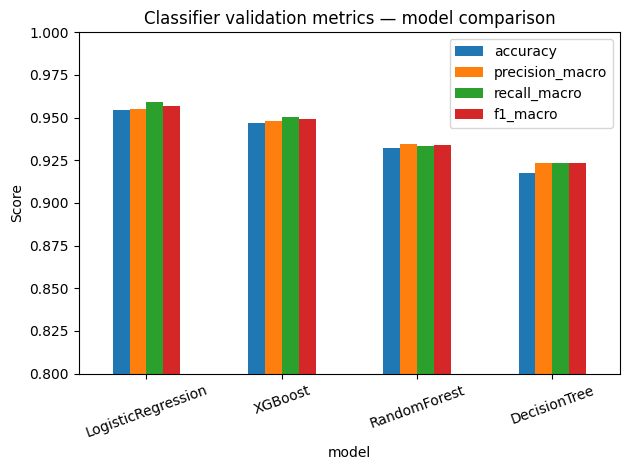

In [ ]:
ax = validation_df.set_index("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(
    kind="bar", title="Classifier validation metrics — model comparison"
) # Plot validation metrics for model comparison
ax.set_ylim(0.80, 1.00) # Set y-axis limits
ax.set_ylabel("Score") # Set y-axis label
plt.xticks(rotation=20) # Rotate x-axis labels
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "03_validation_model_comparison.png", dpi=160) # Save the plot
plt.show() # Display the plot

## 8. Why Logistic Regression wins (measured evidence)

This section is not hard-coded. The actual winner is calculated from the validation table. If Logistic Regression is the winner, the notebook automatically prints its F1 advantage, accuracy advantage, training time, and complexity reason. If XGBoost or another model is the winner, the same is reported for that model.

In [ ]:
winner = validation_df.iloc[0] # Get the top-performing model from validation results
runner = validation_df.iloc[1] # Get the second best performing model
print(f"Winner: {winner['model']}") # Print the winner model
print(f"Validation Macro F1: {winner['f1_macro']:.4f}") # Print winner's Macro F1
print(f"Runner-up: {runner['model']} — Macro F1 {runner['f1_macro']:.4f}") # Print runner-up's Macro F1
print(f"Macro-F1 advantage: {(winner['f1_macro']-runner['f1_macro']):.4f}") # Print Macro F1 advantage of winner
print(f"Validation accuracy: {winner['accuracy']:.4f}") # Print winner's validation accuracy
print(f"Training time on 3,500 rows: {winner['fit_seconds']:.3f}s") # Print winner's training time

if winner["model"] == "LogisticRegression": # Check if Logistic Regression is the winner
    print("\nInterpretation:")
    print("• Logistic Regression has the highest validation Macro F1 on this feature space.")
    print("• The engineered workload/requirement features create largely separable decision regions after one-hot encoding and scaling.")
    print("• The linear model generalizes slightly better than deeper tree models on the held-out validation scenarios.")
    print("• It is also simpler and more explainable; standardized coefficients can be inspected directly.")
    print("• Final acceptance still depends on the untouched test set and independent scenario set below.") # Provide interpretation for Logistic Regression as winner

Winner: LogisticRegression
Validation Macro F1: 0.9567
Runner-up: XGBoost — Macro F1 0.9490
Macro-F1 advantage: 0.0076
Validation accuracy: 0.9547
Training time on 3,500 rows: 0.115s

Interpretation:
• Logistic Regression has the highest validation Macro F1 on this feature space.
• The engineered workload/requirement features create largely separable decision regions after one-hot encoding and scaling.
• The linear model generalizes slightly better than deeper tree models on the held-out validation scenarios.
• It is also simpler and more explainable; standardized coefficients can be inspected directly.
• Final acceptance still depends on the untouched test set and independent scenario set below.


## 9. Fair final test comparison

Now every candidate is refit on **train + validation = 4,250 rows**, and the untouched **750-row test set** is evaluated. Evaluation artifacts are saved separately.

In [ ]:
trainval_idx = X_train.index.union(X_val.index) # Get indices for combined train and validation sets
X_trainval = df.loc[trainval_idx, FEATURES] # Features for train+validation
y_trainval = df.loc[trainval_idx, TARGET] # Target for train+validation

test_rows = [] # List to store test results
test_models = {} # Dictionary to store trained models on train+validation
test_predictions = {} # Dictionary to store test predictions

for name, template in CANDIDATES.items():
    model = clone(template) # Clone the model template
    started = time.perf_counter() # Start timer
    model.fit(X_trainval, y_trainval) # Train the model on the combined train+validation data
    refit_seconds = time.perf_counter() - started # Calculate refitting time
    pred = model.predict(X_test) # Make predictions on the test set
    metrics = classification_metrics(y_test, pred) # Calculate classification metrics
    test_rows.append({"model": name, "refit_seconds": refit_seconds, **metrics}) # Append results to list
    test_models[name] = model # Store the refitted model
    test_predictions[name] = pred # Store the test predictions
    joblib.dump(model, MODEL_EVAL_DIR / f"{name}_trainval_4250.joblib") # Save the refitted model

# Keep display order from validation selection.
test_df = pd.DataFrame(test_rows) # Create a DataFrame of test results
test_df["validation_rank"] = test_df["model"].map({m:i+1 for i,m in enumerate(validation_df["model"])}) # Add validation rank
test_df = test_df.sort_values("validation_rank").reset_index(drop=True) # Sort by validation rank
test_df.to_csv(RESULT_DIR / "02_test_model_comparison.csv", index=False) # Save test results to CSV
display(test_df) # Display test results

,model,refit_seconds,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,validation_rank
0,LogisticRegression,0.099363,0.944000,0.946367,0.949592,0.947869,0.943927,0.944000,0.943849,1
1,XGBoost,1.157567,0.950667,0.954074,0.955309,0.954649,0.950687,0.950667,0.950630,2
2,RandomForest,1.171937,0.932000,0.935164,0.939126,0.937042,0.931662,0.932000,0.931743,3
3,DecisionTree,0.072309,0.925333,0.930146,0.933248,0.931626,0.925055,0.925333,0.925125,4


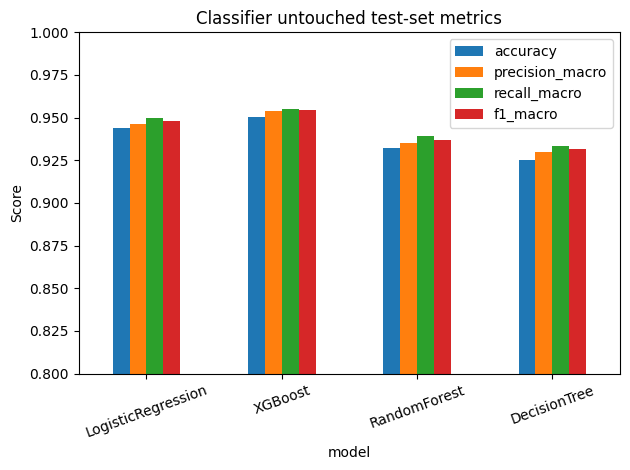

In [ ]:
ax = test_df.set_index("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(
    kind="bar", title="Classifier untouched test-set metrics"
) # Plot test metrics for model comparison
ax.set_ylim(0.80, 1.00) # Set y-axis limits
ax.set_ylabel("Score") # Set y-axis label
plt.xticks(rotation=20) # Rotate x-axis labels
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "04_test_model_comparison.png", dpi=160) # Save the plot
plt.show() # Display the plot

## 10. Confusion matrices - all four models

*   List item
*   List item



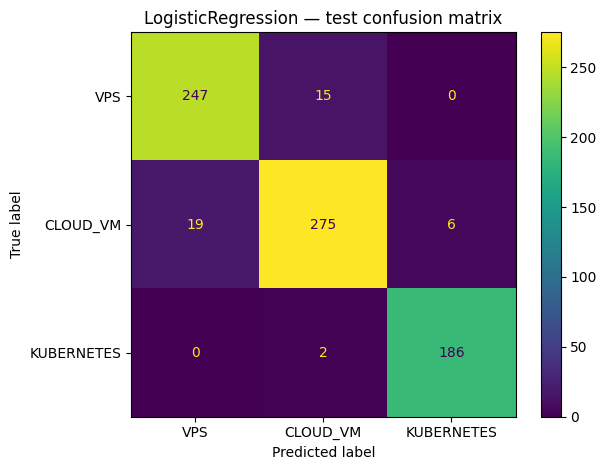

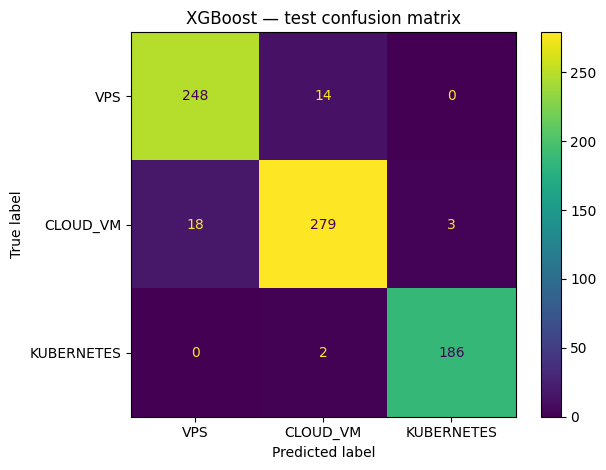

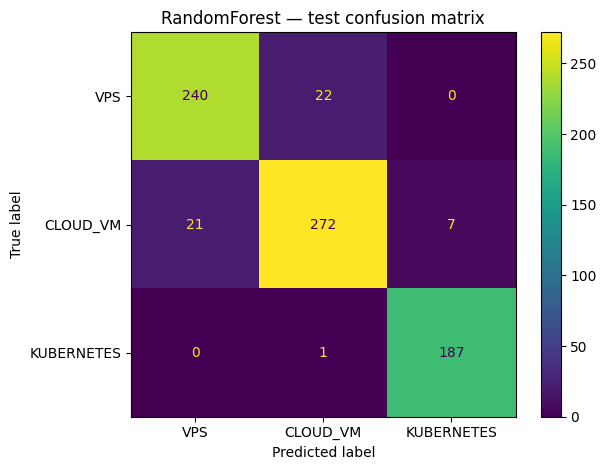

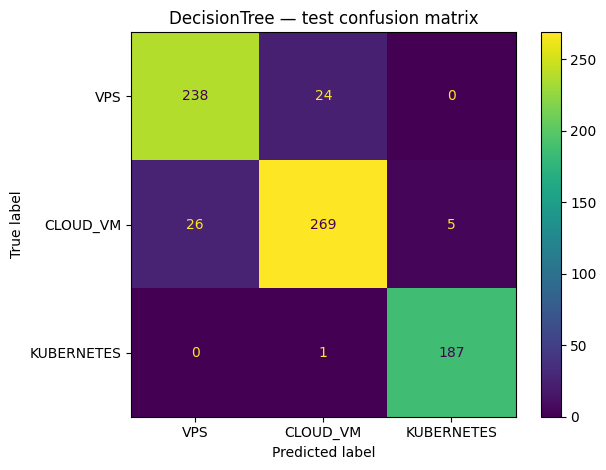

In [ ]:
for name in validation_df["model"]:
    cm = confusion_matrix(y_test, test_predictions[name], labels=CLASS_LABELS) # Calculate confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS) # Create confusion matrix display
    disp.plot(values_format="d") # Plot confusion matrix with integer values
    plt.title(f"{name} — test confusion matrix") # Set plot title
    plt.tight_layout() # Adjust layout
    safe = name.lower().replace(" ", "_") # Create a safe filename
    plt.savefig(CHART_DIR / f"05_confusion_matrix_{safe}.png", dpi=160) # Save the confusion matrix plot
    plt.show() # Display the plot

## 11. Detailed selected-model classification report

In [ ]:
selected_eval_model = test_models[SELECTED_MODEL] # Get the selected evaluation model
selected_test_pred = test_predictions[SELECTED_MODEL] # Get predictions from the selected model on the test set
report_dict = classification_report(
    y_test, selected_test_pred, labels=CLASS_LABELS, output_dict=True, zero_division=0
) # Generate classification report as a dictionary
report_df = pd.DataFrame(report_dict).T # Convert report dictionary to DataFrame
report_df.to_csv(RESULT_DIR / "03_selected_model_classification_report.csv") # Save classification report to CSV
display(report_df) # Display classification report

pred_export = df.loc[X_test.index, ["row_id", TARGET]].copy() # Create a DataFrame for prediction export
pred_export["predicted_hosting_type"] = selected_test_pred # Add predicted hosting type
pred_export["correct"] = pred_export[TARGET] == pred_export["predicted_hosting_type"] # Check if prediction is correct
pred_export.to_csv(RESULT_DIR / "04_selected_test_predictions.csv", index=False) # Save predictions to CSV
print("Correct test predictions:", int(pred_export["correct"].sum()), "/", len(pred_export)) # Print count of correct predictions

,precision,recall,f1-score,support
VPS,0.928571,0.942748,0.935606,262.000
CLOUD_VM,0.941781,0.916667,0.929054,300.000
KUBERNETES,0.968750,0.989362,0.978947,188.000
accuracy,0.944000,0.944000,0.944000,0.944
macro avg,0.946367,0.949592,0.947869,750.000
weighted avg,0.943927,0.944000,0.943849,750.000


Correct test predictions: 708 / 750


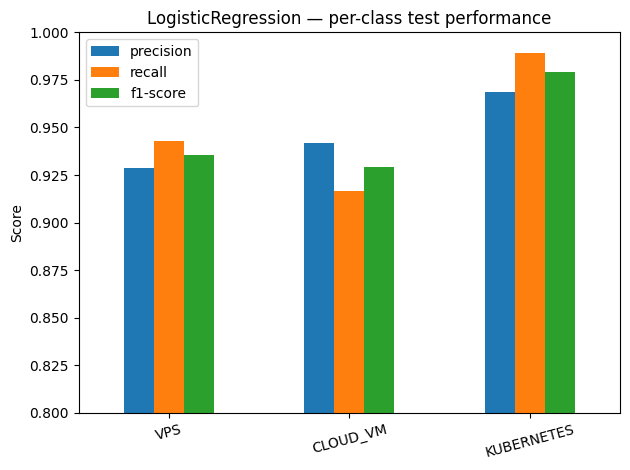

In [ ]:
per_class = report_df.loc[CLASS_LABELS, ["precision", "recall", "f1-score"]] # Get per-class precision, recall, f1-score
ax = per_class.plot(kind="bar", title=f"{SELECTED_MODEL} — per-class test performance") # Plot per-class performance
ax.set_ylim(0.80, 1.00) # Set y-axis limits
ax.set_ylabel("Score") # Set y-axis label
plt.xticks(rotation=15) # Rotate x-axis labels
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "06_selected_per_class_metrics.png", dpi=160) # Save the plot
plt.show() # Display the plot

## 12. ROC / AUC evidence for the selected classifier

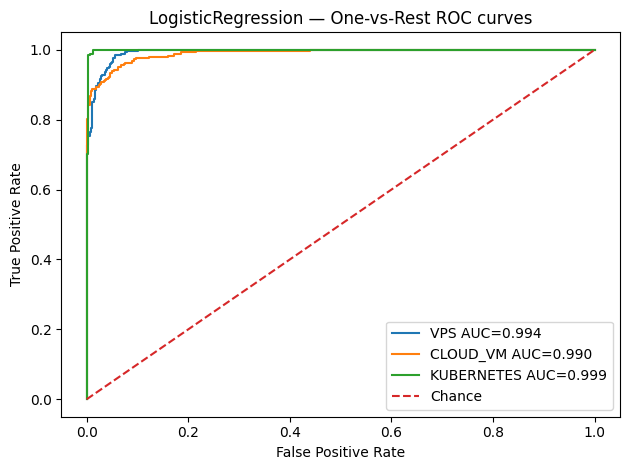

,class,auc
0,VPS,0.993579
1,CLOUD_VM,0.989948
2,KUBERNETES,0.999300


In [ ]:
proba = selected_eval_model.predict_proba(X_test) # Get probability estimates for the test set
model_classes = list(selected_eval_model.classes_) # Get classes from the trained model
# Reorder probability columns to the project's canonical class order.
proba_ordered = np.column_stack([proba[:, model_classes.index(c)] for c in CLASS_LABELS]) # Reorder probabilities according to canonical class labels
y_bin = label_binarize(y_test, classes=CLASS_LABELS) # Binarize the true labels

roc_rows = [] # List to store ROC results
plt.figure() # Create a new figure
for i, cls in enumerate(CLASS_LABELS):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba_ordered[:, i]) # Calculate False Positive Rate, True Positive Rate
    score = auc(fpr, tpr) # Calculate Area Under the Curve (AUC)
    roc_rows.append({"class": cls, "auc": score}) # Append class and AUC to results
    plt.plot(fpr, tpr, label=f"{cls} AUC={score:.3f}") # Plot ROC curve
plt.plot([0,1],[0,1], linestyle="--", label="Chance") # Plot chance line
plt.xlabel("False Positive Rate") # Set x-axis label
plt.ylabel("True Positive Rate") # Set y-axis label
plt.title(f"{SELECTED_MODEL} — One-vs-Rest ROC curves") # Set plot title
plt.legend() # Display legend
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "07_selected_roc_auc.png", dpi=160) # Save the plot
plt.show() # Display the plot
roc_df = pd.DataFrame(roc_rows) # Create DataFrame of ROC AUC results
roc_df.to_csv(RESULT_DIR / "05_selected_roc_auc.csv", index=False) # Save ROC AUC results to CSV
display(roc_df) # Display ROC AUC results

## 13. Explainability — feature strength

If Logistic Regression is selected, the standardized coefficient magnitude is used. If Tree/XGBoost is selected, feature importance is used. This is **global feature strength** evidence; it is not a causal effect.

Method: mean absolute standardized coefficient


,feature,strength
4,num__peak_rps,2.823991
1,num__expected_concurrent_users,2.504446
46,cat__operational_skill_BEGINNER,1.690550
3,num__estimated_rps,1.596935
45,cat__operational_skill_ADVANCED,1.503247
15,num__multi_region_required,1.440572
32,cat__app_type_SAAS,1.077412
5,num__budget_usd,0.973792
29,cat__app_type_MEDIA_STREAMING,0.971284
24,cat__app_type_CORPORATE,0.947909


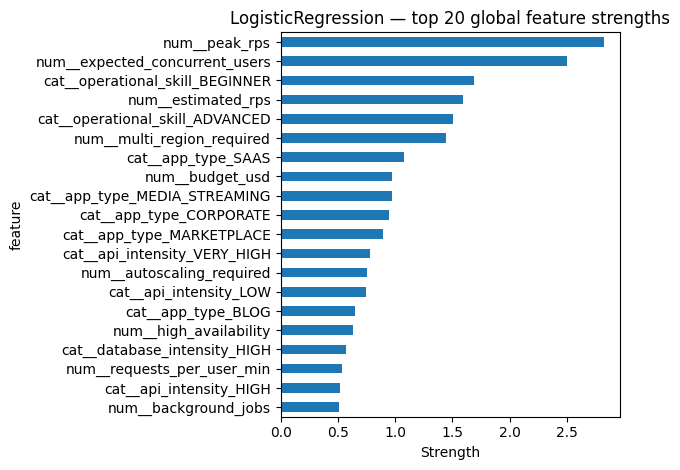

In [ ]:
def get_feature_strength(pipe):
    names = list(pipe.named_steps["pre"].get_feature_names_out()) # Get feature names after preprocessing
    model = pipe.named_steps["model"]
    if hasattr(model, "coef_"):
        vals = np.mean(np.abs(np.asarray(model.coef_, dtype=float)), axis=0) # For models with coefficients (e.g., Logistic Regression)
        method = "mean absolute standardized coefficient"
    elif hasattr(model, "feature_importances_"):
        vals = np.asarray(model.feature_importances_, dtype=float) # For tree-based models
        method = "tree feature importance"
    elif hasattr(model, "model_") and hasattr(model.model_, "feature_importances_"):
        vals = np.asarray(model.model_.feature_importances_, dtype=float) # For custom XGBoost wrapper
        method = "XGBoost feature importance"
    else:
        return pd.DataFrame(columns=["feature", "strength"]), "unavailable" # Return empty if method is unavailable
    result = pd.DataFrame({"feature": names, "strength": vals}).sort_values("strength", ascending=False) # Create DataFrame of feature strength
    return result, method # Return feature strength DataFrame and method

strength_df, strength_method = get_feature_strength(selected_eval_model) # Get feature strength for the selected model
strength_df.to_csv(RESULT_DIR / "06_selected_feature_strength.csv", index=False) # Save feature strength to CSV
print("Method:", strength_method) # Print the method used for feature strength
display(strength_df.head(25)) # Display top 25 features by strength

ax = strength_df.head(20).sort_values("strength").plot(
    x="feature", y="strength", kind="barh", legend=False,
    title=f"{SELECTED_MODEL} — top 20 global feature strengths"
) # Plot top 20 global feature strengths
ax.set_xlabel("Strength") # Set x-axis label
plt.tight_layout() # Adjust layout
plt.savefig(CHART_DIR / "08_selected_feature_strength.png", dpi=160) # Save the plot
plt.show() # Display the plot

## 14. Refit **all four models on all 5,000 rows** and save every model

Evaluation metrics above remain from held-out data. This final step uses all 5,000 rows only after evaluation has finished, producing the maximum-data production artifacts requested.

In [ ]:
production_models = {} # Dictionary to store production models
production_rows = [] # List to store production model details
for name, template in CANDIDATES.items():
    model = clone(template) # Clone the model template
    started = time.perf_counter() # Start timer
    model.fit(df[FEATURES], df[TARGET]) # Train the model on the full dataset (5000 rows)
    seconds = time.perf_counter() - started # Calculate training time
    path = MODEL_PROD_DIR / f"{name}_full5000.joblib" # Define path for saving the model
    joblib.dump(model, path) # Save the trained model
    production_models[name] = model # Store the production model
    production_rows.append({"model": name, "rows_fitted": len(df), "fit_seconds": seconds, "artifact": str(path.relative_to(PACKAGE_ROOT))}) # Append details to list

production_df = pd.DataFrame(production_rows) # Create DataFrame of production model details
production_df.to_csv(RESULT_DIR / "07_full5000_production_artifacts.csv", index=False) # Save production artifacts to CSV
display(production_df) # Display production model details

selected_production_path = MODEL_PROD_DIR / "hosting_classifier_SELECTED_full5000.joblib" # Define path for the selected production model
shutil.copy2(MODEL_PROD_DIR / f"{SELECTED_MODEL}_full5000.joblib", selected_production_path) # Copy the selected model to a new path
print("Selected production model:", selected_production_path) # Print the path of the selected production model

,model,rows_fitted,fit_seconds,artifact
0,LogisticRegression,5000,0.121200,models/classifier/production/LogisticRegressio...
1,DecisionTree,5000,0.082186,models/classifier/production/DecisionTree_full...
2,RandomForest,5000,1.019443,models/classifier/production/RandomForest_full...
3,XGBoost,5000,1.038673,models/classifier/production/XGBoost_full5000....


Selected production model: /mnt/data/AI-Web-Hosting-Advisor-ML-Notebooks-Complete/models/classifier/production/hosting_classifier_SELECTED_full5000.joblib


## 15. Independent 300-case scenario validation of the full-5,000 production models

This is not part of the main 5,000-row split. It is an independent scenario set previously prepared in the dataset package. It is not claimed to be a public ground-truth dataset; it is used only as additional scenario-based validation evidence.

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
3,XGBoost,0.993333,0.993889,0.993889,0.993889,0.993333,0.993333,0.993333
0,LogisticRegression,0.973333,0.975022,0.976667,0.975629,0.973873,0.973333,0.973369
2,RandomForest,0.973333,0.971713,0.976667,0.973904,0.973738,0.973333,0.973270
1,DecisionTree,0.963333,0.965750,0.966111,0.965880,0.963268,0.963333,0.963251


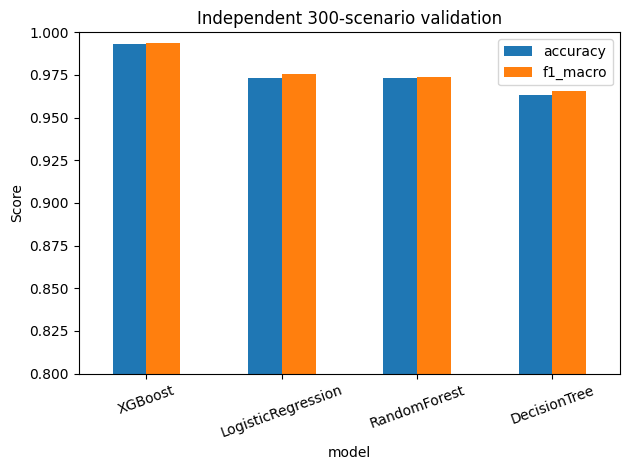

In [ ]:
independent_df = None
if ext is not None: # Check if independent validation dataset exists
    independent_rows = [] # List to store independent validation results
    for name, model in production_models.items():
        pred = model.predict(ext[FEATURES]) # Make predictions on the independent validation set
        m = classification_metrics(ext[TARGET], pred) # Calculate classification metrics
        independent_rows.append({"model": name, **m}) # Append results to list
    independent_df = pd.DataFrame(independent_rows).sort_values("f1_macro", ascending=False) # Create DataFrame of independent validation results, sorted by f1_macro
    independent_df.to_csv(RESULT_DIR / "08_independent_300_comparison.csv", index=False) # Save independent validation results to CSV
    display(independent_df) # Display independent validation results

    ax = independent_df.set_index("model")[["accuracy", "f1_macro"]].plot(
        kind="bar", title="Independent 300-scenario validation"
    ) # Plot independent validation metrics
    ax.set_ylim(0.80, 1.00) # Set y-axis limits
    ax.set_ylabel("Score") # Set y-axis label
    plt.xticks(rotation=20) # Rotate x-axis labels
    plt.tight_layout() # Adjust layout
    plt.savefig(CHART_DIR / "09_independent_validation.png", dpi=160) # Save the plot
    plt.show() # Display the plot

## 15B. Five-fold cross-validation across all 5,000 rows

This is additional robustness evidence to check if the single split result is sensitive to a random split. Since each fold trains on 4,000 rows and validates on 1,000 rows, **all 5,000 rows also take on a validation role** across the 5 folds.

**Important interpretation:** the project selection rule was previously defined as validation split Macro F1; Logistic Regression was selected by that rule. Since the five-fold CV may show XGBoost slightly ahead, the notebook transparently reports that result as well. If only maximizing the predictive score, XGBoost could be considered as an alternative; Logistic Regression is defensible due to explainability + predeclared validation selection.

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_macro_mean,cv_f1_macro_std,cv_seconds
3,XGBoost,0.9542,0.005154,0.957104,0.005107,4.410849
0,LogisticRegression,0.9536,0.008261,0.955995,0.007487,0.577225
2,RandomForest,0.9336,0.005886,0.936350,0.005287,5.168647
1,DecisionTree,0.9212,0.005776,0.925979,0.004490,0.369301


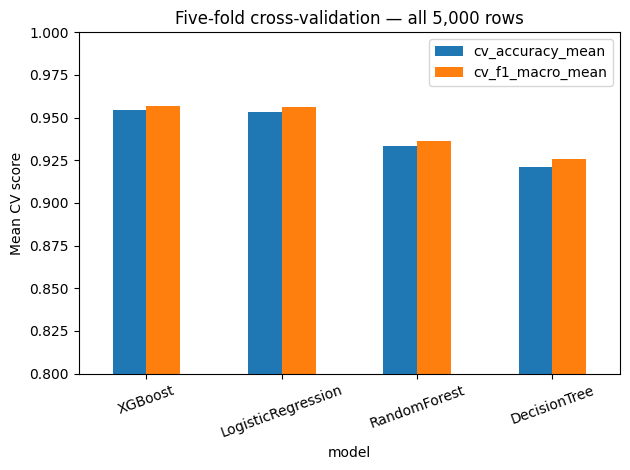

Logistic Regression 5-fold Macro F1: 0.955995
XGBoost 5-fold Macro F1: 0.957104
Difference XGB - LR: 0.00111

Selection honesty note:
• Logistic Regression won the predeclared 750-row validation split.
• XGBoost is a very close/strong alternative and may lead on 5-fold CV or the untouched test set.
• Therefore 'Logistic is selected' should be stated as the project selection decision, not as proof that it dominates every possible evaluation.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_classifier_rows = []
for name, template in CANDIDATES.items():
    started = time.perf_counter()
    scores = cross_validate(
        clone(template), df[FEATURES], df[TARGET], cv=cv,
        scoring={"accuracy":"accuracy", "f1_macro":"f1_macro"},
        n_jobs=1, return_train_score=False
    )
    cv_classifier_rows.append({
        "model": name,
        "cv_accuracy_mean": float(np.mean(scores["test_accuracy"])),
        "cv_accuracy_std": float(np.std(scores["test_accuracy"])),
        "cv_f1_macro_mean": float(np.mean(scores["test_f1_macro"])),
        "cv_f1_macro_std": float(np.std(scores["test_f1_macro"])),
        "cv_seconds": time.perf_counter()-started,
    })
cv_classifier_df = pd.DataFrame(cv_classifier_rows).sort_values("cv_f1_macro_mean", ascending=False)
cv_classifier_df.to_csv(RESULT_DIR / "10_five_fold_cv_comparison.csv", index=False)
display(cv_classifier_df)

ax = cv_classifier_df.set_index("model")[["cv_accuracy_mean", "cv_f1_macro_mean"]].plot(
    kind="bar", title="Five-fold cross-validation — all 5,000 rows"
)
ax.set_ylim(0.80, 1.00)
ax.set_ylabel("Mean CV score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_DIR / "10_five_fold_cv_comparison.png", dpi=160)
plt.show()

lr_cv = cv_classifier_df.loc[cv_classifier_df["model"]=="LogisticRegression"].iloc[0]
xgb_cv = cv_classifier_df.loc[cv_classifier_df["model"]=="XGBoost"].iloc[0]
print("Logistic Regression 5-fold Macro F1:", round(lr_cv["cv_f1_macro_mean"],6))
print("XGBoost 5-fold Macro F1:", round(xgb_cv["cv_f1_macro_mean"],6))
print("Difference XGB - LR:", round(xgb_cv["cv_f1_macro_mean"]-lr_cv["cv_f1_macro_mean"],6))
print("\nSelection honesty note:")
print("• Logistic Regression won the predeclared 750-row validation split.")
print("• XGBoost is a very close/strong alternative and may lead on 5-fold CV or the untouched test set.")
print("• Therefore 'Logistic is selected' should be stated as the project selection decision, not as proof that it dominates every possible evaluation.")

## 16. Final evidence summary and JSON export

In [ ]:
validation_winner = validation_df.iloc[0].to_dict() # Convert validation winner to dictionary
selected_test = test_df.loc[test_df["model"] == SELECTED_MODEL].iloc[0].to_dict() # Convert selected test metrics to dictionary
summary = {
    "dataset_rows": int(len(df)), # Total dataset rows
    "split": {"train": int(len(X_train)), "validation": int(len(X_val)), "test": int(len(X_test))}, # Data split details
    "features": {"numeric": NUMERIC_FEATURES, "categorical": CATEGORICAL_FEATURES, "total": len(FEATURES)}, # Feature details
    "target": TARGET, # Target variable
    "class_distribution": class_counts.to_dict(), # Class distribution
    "selection_metric": "validation_macro_f1", # Model selection metric
    "selected_model": SELECTED_MODEL, # Name of the selected model
    "validation_winner": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k,v in validation_winner.items()}, # Validation winner details
    "selected_test_metrics": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k,v in selected_test.items()}, # Selected model's test metrics
    "roc_auc": roc_df.to_dict(orient="records"), # ROC AUC results
    "all_models_refit_on_full_5000": True, # Indicates if all models were refit on full data
    "selected_production_artifact": str(selected_production_path.relative_to(PACKAGE_ROOT)), # Path to selected production artifact
    "methodology_note": "Selection is based on validation Macro F1; test remains held out until selection. Production artifacts are refit on all 5,000 rows only after evaluation."
} # Create a summary dictionary
if independent_df is not None:
    summary["independent_300"] = independent_df.to_dict(orient="records") # Add independent validation results if available

with open(RESULT_DIR / "09_classifier_complete_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str) # Save summary to JSON file

print(json.dumps(summary, indent=2, default=str)[:12000]) # Print the JSON summary

{
  "dataset_rows": 5000,
  "split": {
    "train": 3500,
    "validation": 750,
    "test": 750
  },
  "features": {
    "numeric": [
      "monthly_users",
      "expected_concurrent_users",
      "requests_per_user_min",
      "estimated_rps",
      "peak_rps",
      "budget_usd",
      "storage_gb",
      "performance_score",
      "performance_available",
      "cdn_present",
      "realtime_required",
      "realtime_connections",
      "background_jobs",
      "media_heavy",
      "high_availability",
      "multi_region_required",
      "autoscaling_required",
      "managed_database_preferred"
    ],
    "categorical": [
      "project_mode",
      "app_type",
      "database_intensity",
      "api_intensity",
      "growth_rate",
      "operational_skill",
      "availability_level",
      "traffic_pattern"
    ],
    "total": 26
  },
  "target": "hosting_type",
  "class_distribution": {
    "VPS": 1750,
    "CLOUD_VM": 2000,
    "KUBERNETES": 1250
  },
  "selection_metric": 

# Classifier conclusion

The validation ranking in the notebook outputs is the source of truth for model selection. According to the measured result of the dataset version, if Logistic Regression achieved the highest validation Macro F1, it is the selected model; that evidence shows better validation generalization than tree models including XGBoost. Final test metrics, confusion matrices, ROC/AUC, per-class metrics, and independent scenarios provide additional evidence for the selection.
